In [15]:
import numpy as np
import pandas as pd

np.random.seed(42)
set1no = 900
set2no = 100

df1=pd.DataFrame({
    "feature1":np.random.normal(loc=0,scale=1,size=set1no),
    "feature2":np.random.normal(loc=0,scale=1,size=set1no),
    "target":[0]*set1no
})
df2=pd.DataFrame({
    "feature1":np.random.normal(loc=2,scale=1,size=set2no),
    "feature2":np.random.normal(loc=2,scale=1,size=set2no),
    "target":[1]*set2no
})
df=pd.concat([df1,df2]).reset_index(drop=True)
df

,feature1,feature2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
995,1.629989,3.070150,1
996,1.741204,1.973479,1
997,3.598647,1.118125,1
998,2.560919,1.836933,1


In [16]:
df_minority = df[df["target"] == 1]
df_majority = df[df["target"] == 0]
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority,replace=True, n_samples=len(df_majority),random_state=42)

df_majority_downsampled = resample(df_majority,replace=True,n_samples=len(df_minority),random_state=42)
df_majority_downsampled


,feature1,feature2,target
102,-0.342715,0.059630,0
435,0.074095,-0.337086,0
860,0.202923,1.639965,0
270,1.441273,0.758929,0
106,1.886186,0.895193,0
...,...,...,...
201,0.560785,-2.896255,0
269,0.130741,0.853416,0
862,1.547505,0.075434,0
815,-1.485560,-0.090533,0


In [17]:
from imblearn.over_sampling import SMOTE   
oversample = SMOTE()
(X, y) = oversample.fit_resample(df[['feature1', 'feature2']], df['target'])
oversample_df = pd.concat([df1,df2],axis=1)
X,y

(      feature1  feature2
 0     0.496714  0.368673
 1    -0.138264 -0.393339
 2     0.647689  0.028745
 3     1.523030  1.278452
 4    -0.234153  0.191099
 ...        ...       ...
 1795  2.701868  1.826691
 1796  3.545917  0.664057
 1797  3.358114  1.774219
 1798  2.486916  1.852372
 1799  2.504733  0.885630
 
 [1800 rows x 2 columns],
 0       0
 1       0
 2       0
 3       0
 4       0
        ..
 1795    1
 1796    1
 1797    1
 1798    1
 1799    1
 Name: target, Length: 1800, dtype: int64)

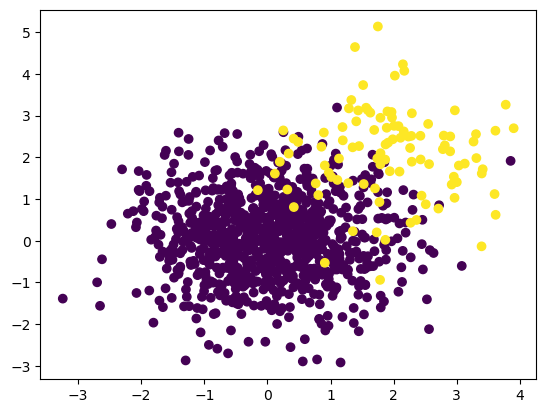

In [18]:
import matplotlib.pyplot as plt
plt.scatter(df["feature1"],df["feature2"],c = df["target"])

In [19]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
df = sns.load_dataset("titanic")
df[["sex","class","embark_town"]].isna().sum()


sex            0
class          0
embark_town    2
dtype: int64

In [20]:
#label encoder
label_encoder = LabelEncoder()
df_label = df.copy()
df_label

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [21]:
df_label["sex"] = label_encoder.fit_transform(df_label["sex"])
df_label

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,0,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,0,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,1,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [22]:
#ordinal encoder
class_order = ["Third","Second","First"]
df_ordinal = df.copy()
ordinal_encoder = OrdinalEncoder(categories=[class_order])
df_ordinal["class"] = ordinal_encoder.fit_transform(df_ordinal[["class"]])
df_ordinal

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,0.0,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,2.0,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,0.0,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,2.0,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,0.0,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1.0,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,2.0,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,0.0,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,2.0,man,True,C,Cherbourg,yes,True
